In [1]:
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')
df.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [4]:
df.shape

(891, 15)

In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 1. Simple Elimination (Deletion)
idle to apply when we need to remove upto 20% of the data. It is not recommended to use this method when we have a small dataset. It is also not recommended to use this method when we have a large dataset with a lot of missing values.

In [5]:
df_cleaned = df.dropna(subset=['embark_town','embarked'])

In [6]:
df_cleaned.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

### 2. Statistical Imputation
Mean/Median/Mode

In [7]:
from sklearn.impute import SimpleImputer

<Axes: xlabel='age'>

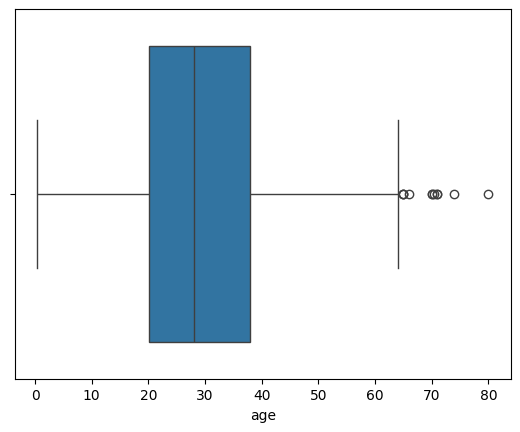

In [8]:
sns.boxplot(x=df['age'])

In [9]:
# outlier exist so we picked median for imputation
num_imputer = SimpleImputer(strategy='median')
df['age'] = num_imputer.fit_transform(df[['age']])

In [10]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
df["embarked"].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
cat_imp = SimpleImputer(strategy='most_frequent') #mode
df['embarked'] = cat_imp.fit_transform(df[['embarked']]).ravel()

In [14]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 3. Multivariate Imputation (Iterative Imputation)
Advanced. use a ml model to predict the missing values based on the other features in the dataset.

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

it = IterativeImputer(random_state=4)
# use relevent numeric cols to estimate the age
df[["age","pclass", "fare"]] = it.fit_transform(df[["age","pclass", "fare"]])

In [17]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### 4. KNN Imputation
calculate the distance between the missing value and the other values in the dataset and then impute the missing value with the mean of the k nearest neighbors.

In [18]:
df = sns.load_dataset('titanic')
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [19]:
from sklearn.impute import KNNImputer

In [21]:
knn = KNNImputer(n_neighbors=5)
df["age"] = knn.fit_transform(df[["age"]])

In [22]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64